# Data Exploration - BAMBI Dataset

**Team Member:** Celina Binder

This notebook explores the BAMBI wildlife drone dataset to understand its structure and contents.

In [1]:
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/code_2')

from utils.dataset import get_data_stats, load_yolo_labels

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from utils.dataset import get_data_stats, load_yolo_labels

## Dataset Paths

In [4]:
DATA_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
TRAIN_IMG = DATA_DIR / 'images' / 'train'
VAL_IMG = DATA_DIR / 'images' / 'val'
TEST_IMG = DATA_DIR / 'images' / 'test'

TRAIN_LABELS = DATA_DIR / 'labels' / 'train'
VAL_LABELS = DATA_DIR / 'labels' / 'val'
TEST_LABELS = DATA_DIR / 'labels' / 'test'

## Dataset Statistics

In [5]:
stats = get_data_stats(str(DATA_DIR))
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}:")
    print(f"  Images: {stats[split].get('num_images', 0)}")
    print(f"  Labels: {stats[split].get('num_labels', 0)}")
    print(f"  Total objects: {stats[split].get('total_objects', 0)}")


TRAIN:
  Images: 14619
  Labels: 14185
  Total objects: 54731

VAL:
  Images: 2384
  Labels: 2481
  Total objects: 10418

TEST:
  Images: 2483
  Labels: 2418
  Total objects: 6151


## Sample Images with Annotations
- uses the YOLO format which stores normalized coordinates (0-1), which are scaled by each image's actual width/height

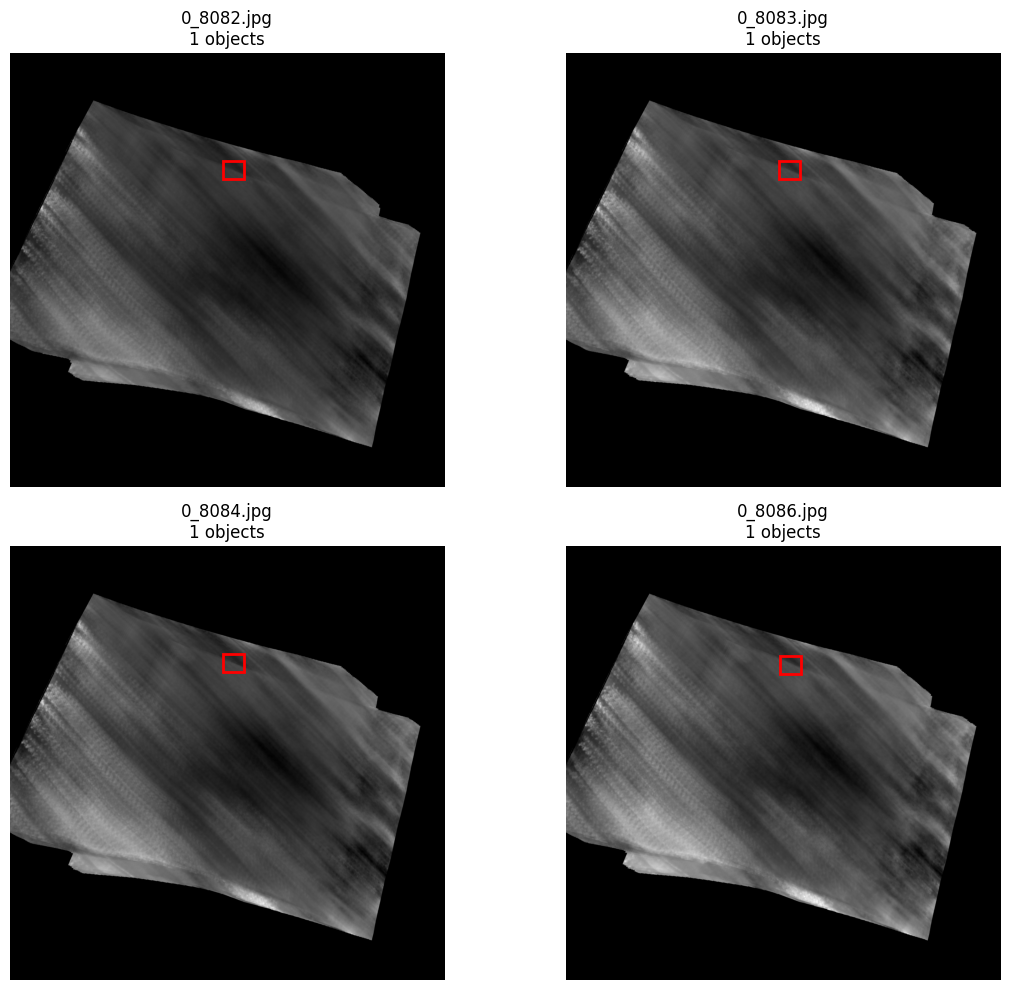

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

train_images = sorted(list(TRAIN_IMG.glob('*.jpg')))[:4]

for i, img_path in enumerate(train_images):
    label_path = TRAIN_LABELS / f"{img_path.stem}.txt"
    
    img = Image.open(img_path)
    width, height = img.size
    
    axes[i].imshow(img)
    
    if label_path.exists():
        bboxes = load_yolo_labels(str(label_path))
        for bbox in bboxes:
            cx = bbox['x_center'] * width
            cy = bbox['y_center'] * height
            w = bbox['width'] * width
            h = bbox['height'] * height
            
            rect = plt.Rectangle(
                (cx - w/2, cy - h/2), w, h,
                fill=False, edgecolor='red', linewidth=2
            )
            axes[i].add_patch(rect)
    
    axes[i].axis('off')
    axes[i].set_title(f"{img_path.name}\n{len(bboxes)} objects")

plt.tight_layout()
plt.show()

## Class Distribution

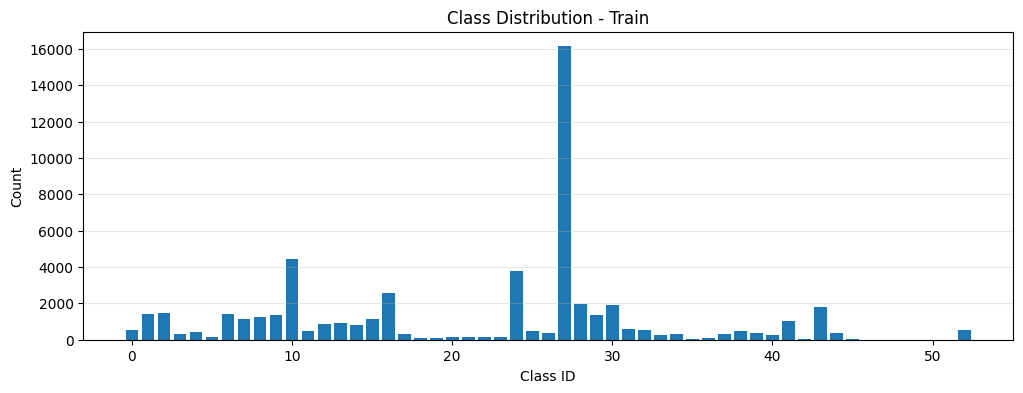

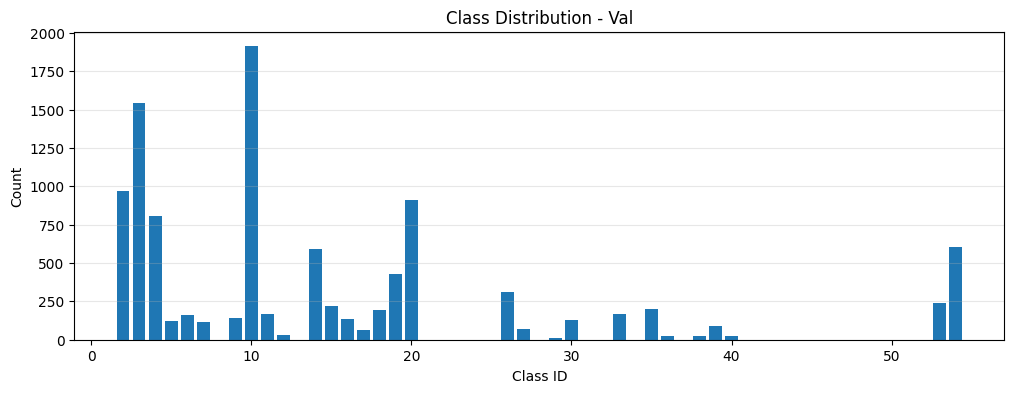

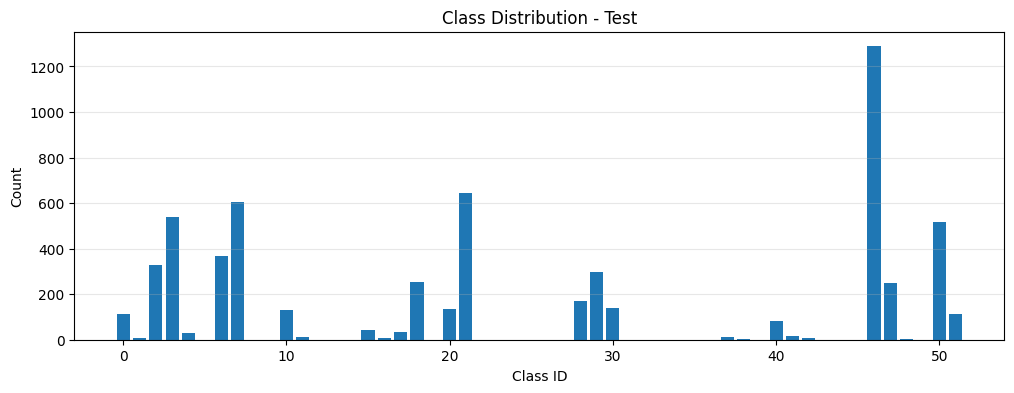

In [ ]:
for split in ['train', 'val', 'test']:
    counts = stats[split].get('class_counts', {})
    if counts:
        plt.figure(figsize=(12, 4))
        plt.bar(counts.keys(), counts.values())
        plt.xlabel('Class ID')
        plt.ylabel('Count')
        plt.title(f'Class Distribution - {split.capitalize()}')
        plt.grid(axis='y', alpha=0.3)
        plt.show()

## Bounding Box Size Distribution

In [ ]:
widths, heights = [], []
for label_file in TRAIN_LABELS.glob('*.txt'):
    bboxes = load_yolo_labels(str(label_file))
    for bbox in bboxes:
        widths.append(bbox['width'])
        heights.append(bbox['height'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=50, edgecolor='black')
axes[0].set_xlabel('Relative Width')
axes[0].set_ylabel('Count')
axes[0].set_title('Bounding Box Width Distribution')

axes[1].hist(heights, bins=50, edgecolor='black')
axes[1].set_xlabel('Relative Height')
axes[1].set_ylabel('Count')
axes[1].set_title('Bounding Box Height Distribution')

plt.tight_layout()
plt.show()

print(f"Avg bbox width: {np.mean(widths):.3f}, height: {np.mean(heights):.3f}")

KeyboardInterrupt: 

## Key Observations
- Dataset contains thermal aerial images
- Multiple animal classes with varying frequencies
- Bounding boxes are relatively small relative to image size